Focuses exclusively on logistics performance:

Speed

Delays

Capacity strain

Cost vs delivery outcomes

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Paths
order_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv")
item_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_item_level.csv")

# Load data
orders = pd.read_csv(
    order_path,
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

items = pd.read_csv(item_path)


### Q2 Average Delivery Time by Region / State / City
Metrics

delivery_time_days (already engineered)

### State-level analysis

In [4]:
state_delivery = orders.groupby("customer_state").agg(
    avg_delivery_time = ("delivery_time_days", "mean"),
    order_count = ("order_id", "nunique")
).sort_values("avg_delivery_time", ascending=False)

state_delivery.head()

,avg_delivery_time,order_count
customer_state,,
RR,28.975610,46
AP,26.731343,68
AM,25.986207,148
AL,24.040302,413
PA,23.316068,975


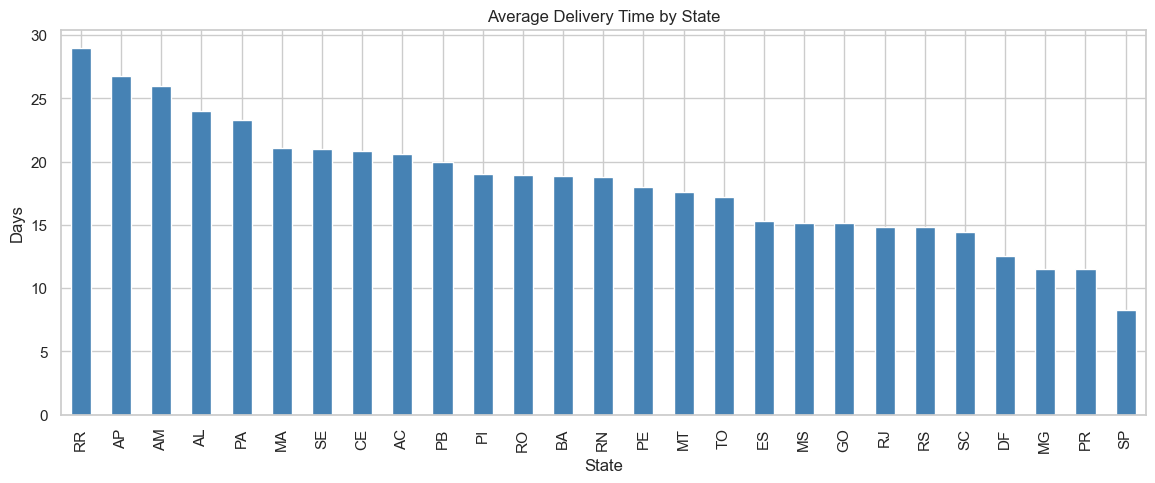

In [5]:
state_delivery["avg_delivery_time"].plot(
    kind="bar",
    figsize=(14,5),
    color="steelblue"
)
plt.title("Average Delivery Time by State")
plt.ylabel("Days")
plt.xlabel("State")
plt.show()


Insight angles

Logistics inequality

Distance from fulfillment centers

Infrastructure gaps

### Q3 Highest Delivery Delays vs Estimated Dates
Metrics

delivery_delay_days

Delay flag

In [6]:
orders["is_late"] = orders["delivery_delay_days"] > 0


### Delay by state

In [7]:
delay_by_state = orders.groupby("customer_state").agg(
    avg_delay = ("delivery_delay_days", "mean"),
    late_rate = ("is_late", "mean")
).sort_values("late_rate", ascending=False)

delay_by_state.head()

,avg_delay,late_rate
customer_state,,
AL,-8.168766,0.220339
MA,-8.966527,0.180723
SE,-9.453731,0.145714
PI,-10.707983,0.145455
CE,-10.186865,0.142216


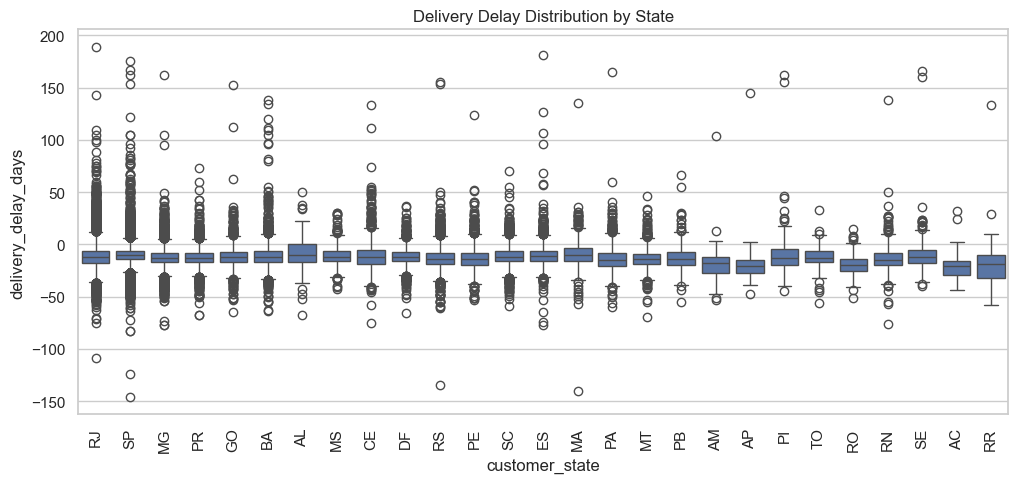

In [8]:
plt.figure(figsize=(12,5))
sns.boxplot(
    x="customer_state",
    y="delivery_delay_days",
    data=orders
)
plt.xticks(rotation=90)
plt.title("Delivery Delay Distribution by State")
plt.show()


Insight angles

Chronic underestimation of delivery promises

States consistently missing SLAs

### Q12 — Items per Order vs Delivery Delay

Why this matters

More items → more complexity → higher logistics risk

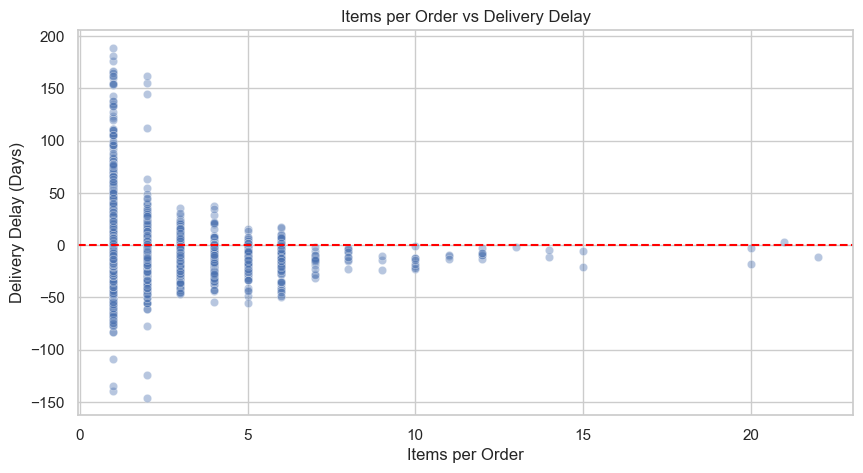

In [9]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x="items_per_order",
    y="delivery_delay_days",
    data=orders,
    alpha=0.4
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Items per Order vs Delivery Delay")
plt.xlabel("Items per Order")
plt.ylabel("Delivery Delay (Days)")
plt.show()


#### Bucketed view

In [10]:
orders["item_bucket"] = pd.cut(
    orders["items_per_order"],
    bins=[0,1,2,3,5,10,100],
    labels=["1","2","3","4–5","6–10","10+"]
)

bucket_delay = orders.groupby("item_bucket").agg(
    avg_delay=("delivery_delay_days", "mean"),
    late_rate=("is_late", "mean")
)

bucket_delay


C:\Users\Admin\AppData\Local\Temp\ipykernel_32460\2065410585.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_delay = orders.groupby("item_bucket").agg(


,avg_delay,late_rate
item_bucket,,
1,-11.154840,0.075596
2,-12.269053,0.061299
3,-12.654349,0.057795
4–5,-12.773239,0.056088
6–10,-13.658333,0.064777
10+,-8.666667,0.055556


Insight

Multi-item orders experience higher delay probability

Order consolidation tradeoff is visible

### Q9 Shipping Cost vs Delivery Speed

#### Scatter analysis

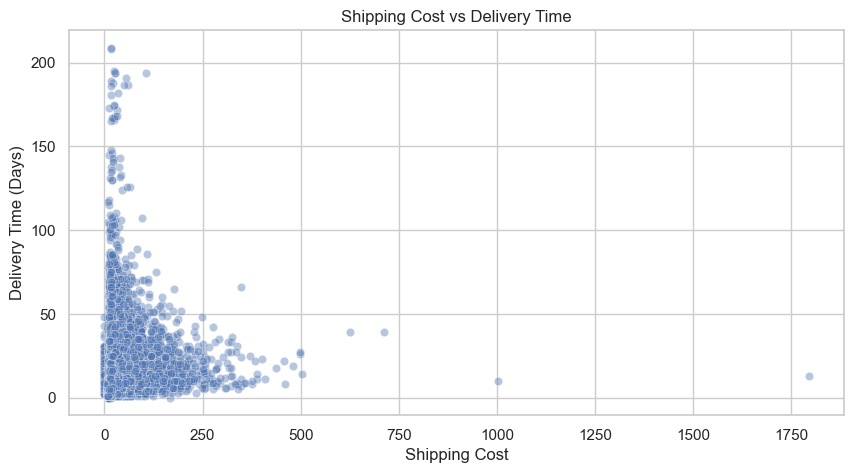

In [11]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x="total_freight",
    y="delivery_time_days",
    data=orders,
    alpha=0.4
)
plt.title("Shipping Cost vs Delivery Time")
plt.xlabel("Shipping Cost")
plt.ylabel("Delivery Time (Days)")
plt.show()


### Correlation check

In [12]:
orders[["total_freight", "delivery_time_days"]].corr()


,total_freight,delivery_time_days
total_freight,1.00000,0.16701
delivery_time_days,0.16701,1.00000


Insight

Higher shipping cost ≠ faster delivery

Pricing inefficiency in logistics

### +1  Delay risk segmentation

In [13]:
orders["delay_risk"] = pd.cut(
    orders["delivery_delay_days"],
    bins=[-100,0,3,7,100],
    labels=["On-time/Early","Slight Delay","Moderate Delay","Severe Delay"]
)

orders["delay_risk"].value_counts(normalize=True) * 100


delay_risk
On-time/Early     92.462046
Severe Delay       3.235441
Slight Delay       2.441098
Moderate Delay     1.861415
Name: proportion, dtype: float64

Gives operational risk tiers

### +2 Late-delivery concentration (Pareto-style)

In [14]:
late_orders = orders[orders["is_late"]]

state_late_contribution = late_orders["customer_state"].value_counts(normalize=True).cumsum()

state_late_contribution.head(10)


customer_state
SP    0.295293
RJ    0.513410
MG    0.594691
BA    0.653530
RS    0.701697
SC    0.746169
ES    0.778462
PR    0.809387
CE    0.835386
PE    0.857827
Name: proportion, dtype: float64

*** Key findings ***

- Delivery performance varies significantly by region

- Certain states experience chronic delays

- Multi-item orders are more delay-prone

- Shipping cost does not reliably improve delivery speed

- Late deliveries are concentrated in a small subset of regions

*** Transition ***

- The next notebook will link these delivery outcomes to customer satisfaction and review behavior, closing the loop between operations and perception.